In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [12]:
# Base folder and embryo groups
dataset_folder = '/mnt/Data1/Nick/transcription_pipeline/'


embryo_list = {
    '001': [
        'test_data/NSPARC/2025-08-29/MCP-mSG_His-RFP_RBS(001)(trans-het)_embryo02',
        'test_data/NSPARC/2025-09-02/MCP-mSG_His-RFP_RBS(001)(trans-het)_embryo01',
        'test_data/NSPARC/2025-09-09/MCP-mSG_His-RFP_RBS(001)(trans-het)_embryo01',
        'test_data/NSPARC/2025-09-12/MCP-mSG_His-RFP_RBS(001)(trans-het)_embryo01',
    ],
    '002': [
        'test_data/NSPARC/2025-08-28/MCP-mSG_His-RFP_RBS(002)(trans-het)_embryo03',
        'test_data/NSPARC/2025-09-12/MCP-mSG_His-RFP_RBS(002)(trans-het)_embryo01',
        'test_data/NSPARC/2025-09-12/MCP-mSG_His-RFP_RBS(002)(trans-het)_embryo02',
        'test_data/NSPARC/2025-09-19/MCP-mSG_His-RFP_RBS(002)(trans-het)_embryo02',
        'test_data/NSPARC/2025-09-19/MCP-mSG_His-RFP_RBS(002)(trans-het)_embryo03',
    ],
    '003': [
        'test_data/NSPARC/2025-08-28/MCP-mSG_His-RFP_RBS(003)(trans-het)_embryo01',
        'test_data/NSPARC/2025-09-02/MCP-mSG_His-RFP_RBS(003)(trans-het)_embryo01',
        'test_data/NSPARC/2025-09-02/MCP-mSG_His-RFP_RBS(003)(trans-het)_embryo02',
        'test_data/NSPARC/2025-09-02/MCP-mSG_His-RFP_RBS(003)(trans-het)_embryo03',
        'test_data/NSPARC/2025-09-09/MCP-mSG_His-RFP_RBS(003)(trans-het)_embryo02',
    ]
}


In [13]:
# Helper to load summary dataframe and compute fraction active

def load_fraction_summary(ds_path):
    pkl_path = os.path.join(dataset_folder, ds_path, 'fraction_active_time_filtered.pkl')
    if not os.path.isfile(pkl_path):
        return None
    df = pd.read_pickle(pkl_path)
    # Expect columns: ap_bin_center, num_spots, num_nuclei
    df = df.copy()

    # Create fraction_active with NaN where num_nuclei is 0
    n = df['num_nuclei'].to_numpy()
    frac = np.full_like(n, np.nan, dtype=float)
    mask = n > 0
    frac[mask] = np.divide(df['num_spots'].to_numpy()[mask], n[mask])
    df['fraction_active'] = np.minimum(frac, 1.0)

    # Binomial standard error sqrt(p(1-p)/n), only where n>0
    err = np.full_like(df['fraction_active'], np.nan, dtype=float)
    p = df['fraction_active'].to_numpy()
    valid = n > 0
    err[valid] = np.sqrt(p[valid] * (1 - p[valid]) / n[valid])
    df['fraction_se'] = err
    return df


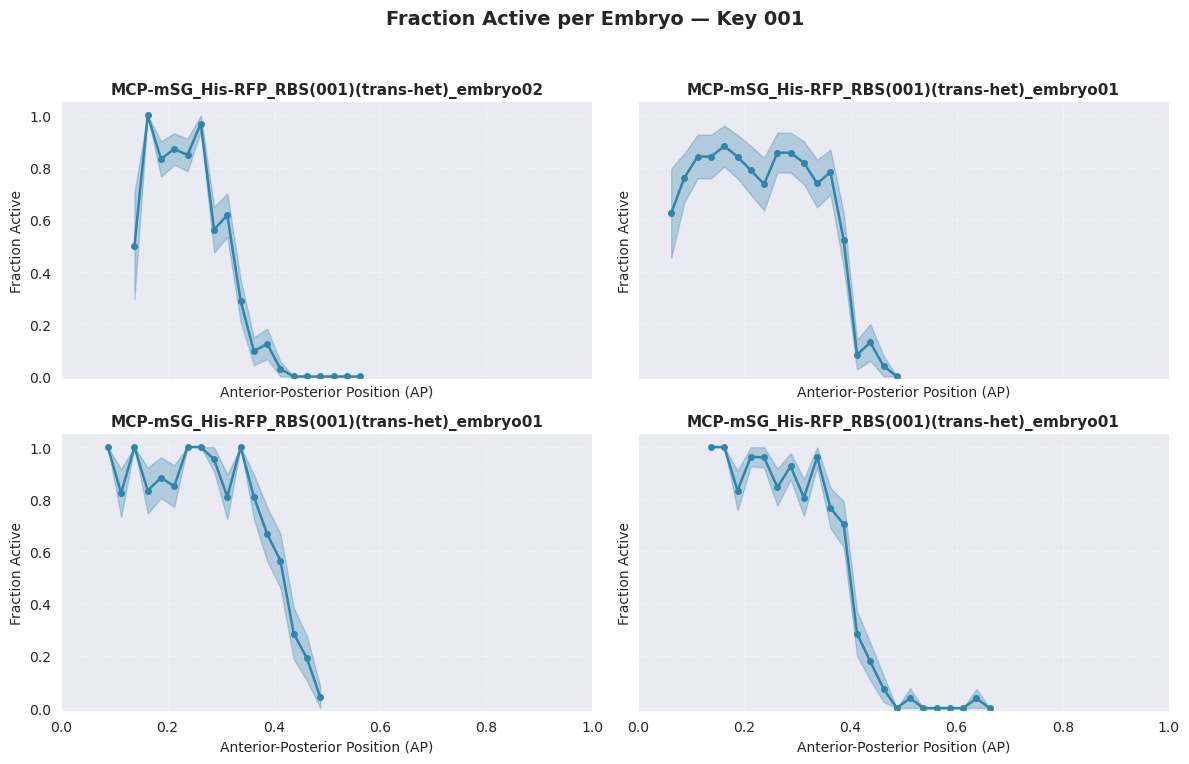

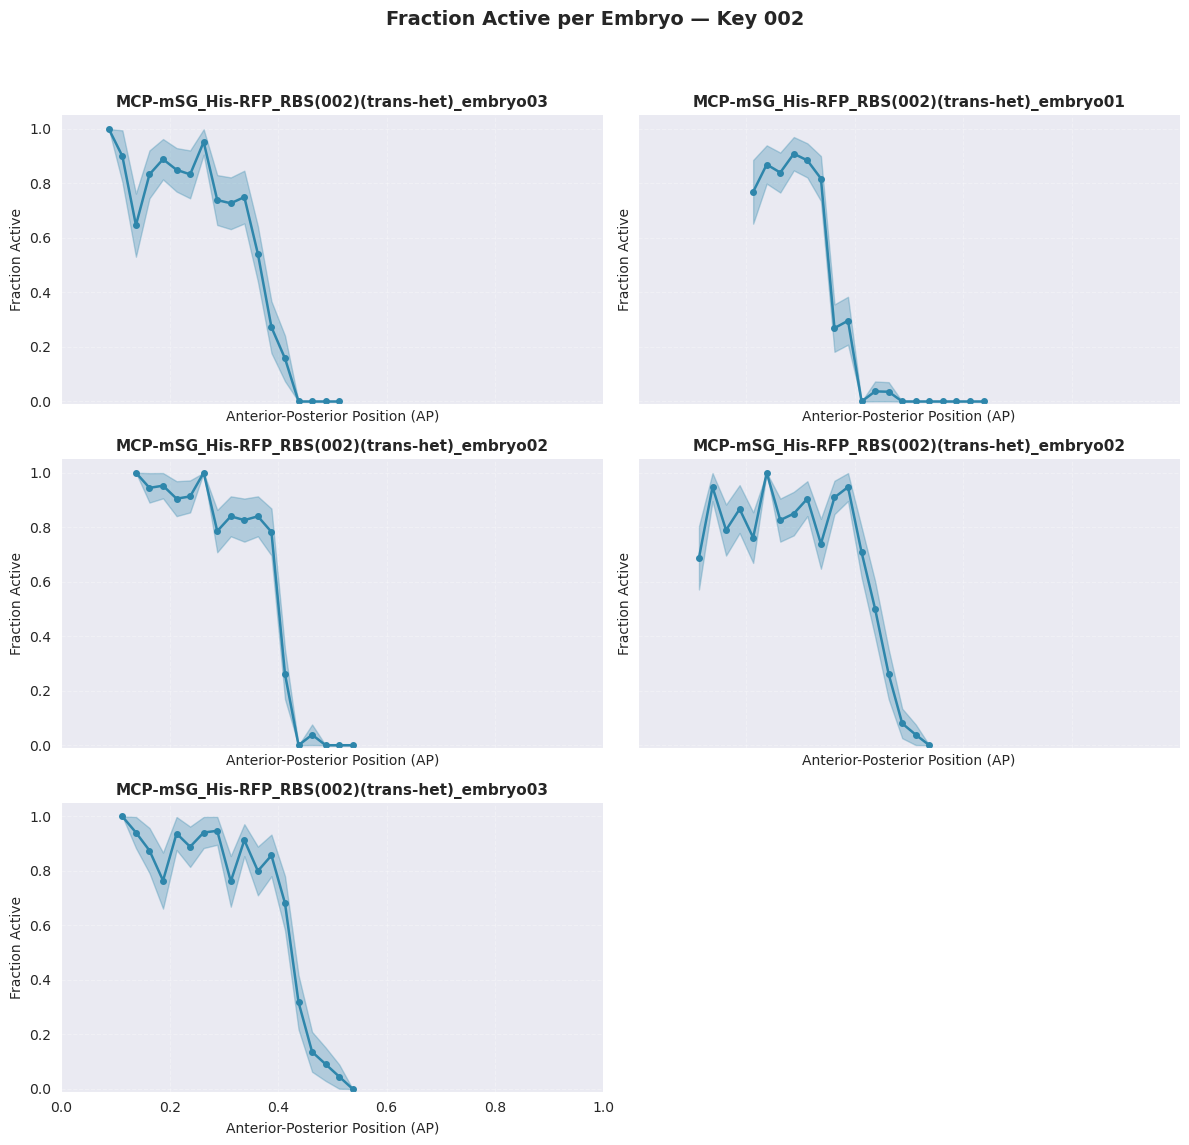

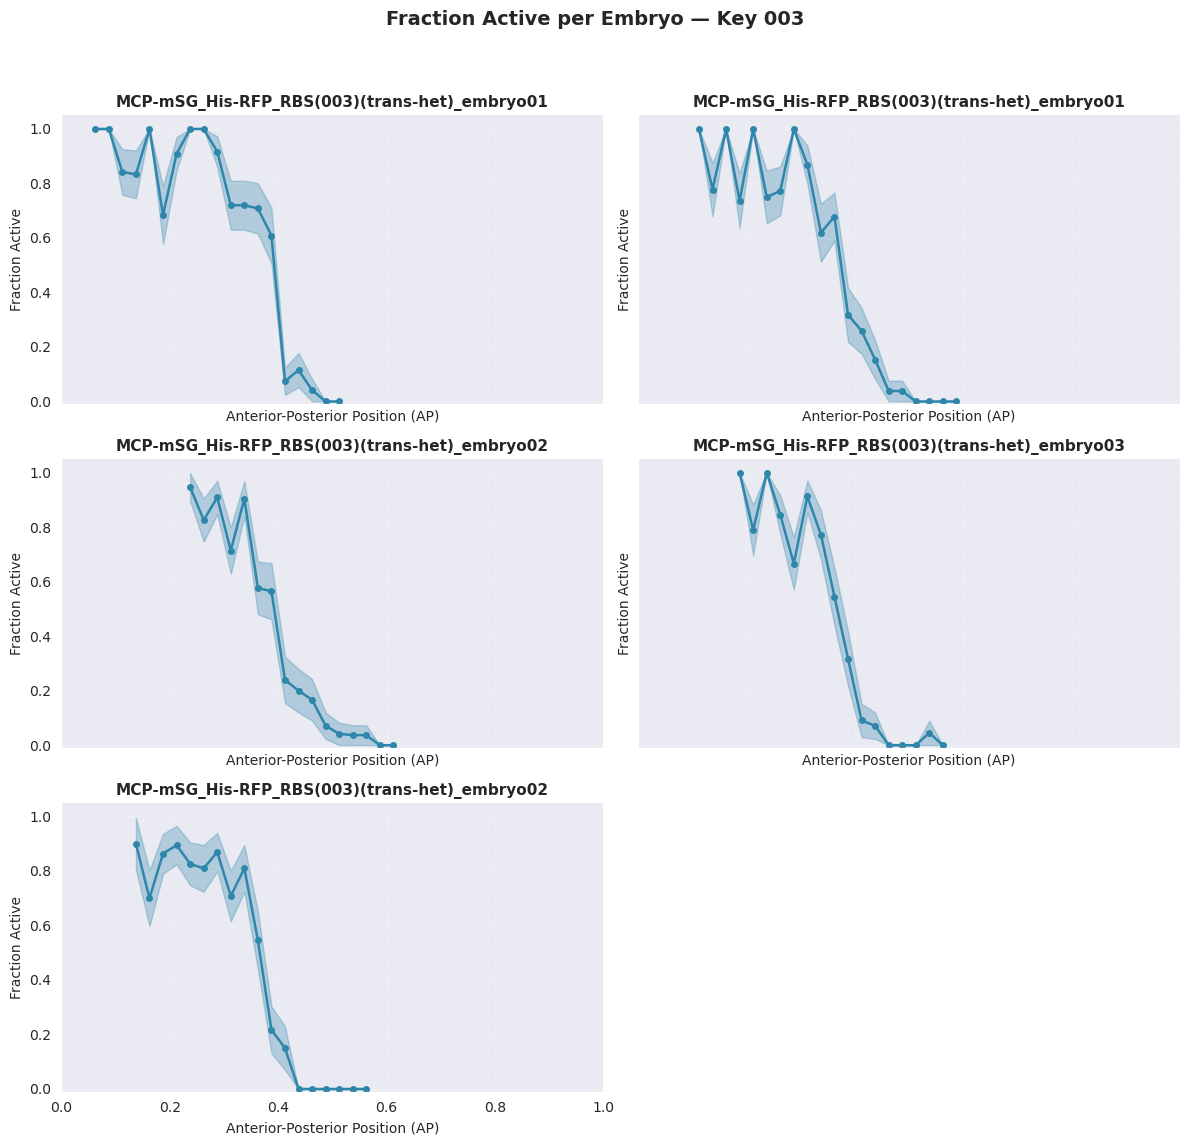

In [14]:
# Plot fraction active for all embryos across all keys

for group_key, embryos in embryo_list.items():
    # Load all available datasets for this key
    loaded = []
    labels = []
    for ds in embryos:
        df = load_fraction_summary(ds)
        if df is not None:
            loaded.append(df)
            labels.append(os.path.basename(ds))
    if not loaded:
        continue

    n_emb = len(loaded)
    ncols = 2
    nrows = int(np.ceil(n_emb / ncols))

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 4*nrows), sharex=True, sharey=True)
    axes = np.array(axes).reshape(-1)  # flatten in case of single row/col

    for i, (df, lab) in enumerate(zip(loaded, labels)):
        ax = axes[i]
        x = df['ap_bin_center'].to_numpy()
        y = df['fraction_active'].to_numpy()
        se = df['fraction_se'].to_numpy()

        # Provided plotting style
        ax.plot(x, y, linestyle='-', marker='o', markersize=4, color='#2E86AB', linewidth=1.8, label='Fraction Active')
        ax.fill_between(x, np.maximum(y - se, 0), np.minimum(y + se, 1.0), alpha=0.3, color='#2E86AB', label='Standard Error')

        ax.set_title(lab, fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    # Hide any unused subplots
    for j in range(i+1, len(axes)):
        axes[j].axis('off')

    fig.suptitle(f'Fraction Active per Embryo — Key {group_key}', fontsize=14, fontweight='bold')
    for ax in axes:
        ax.set_ylim(-0.01, 1.05)
        ax.set_xlim(left=0.0, right=1.0)
        ax.set_xlabel('Anterior-Posterior Position (AP)')
        ax.set_ylabel('Fraction Active')
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


/tmp/ipykernel_3576363/396476670.py:13: RuntimeWarning: Mean of empty slice
  mean_frac = np.nanmean(Y, axis=0)
/mnt/Data1/Nick/miniforge3/envs/transcription_pipeline/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


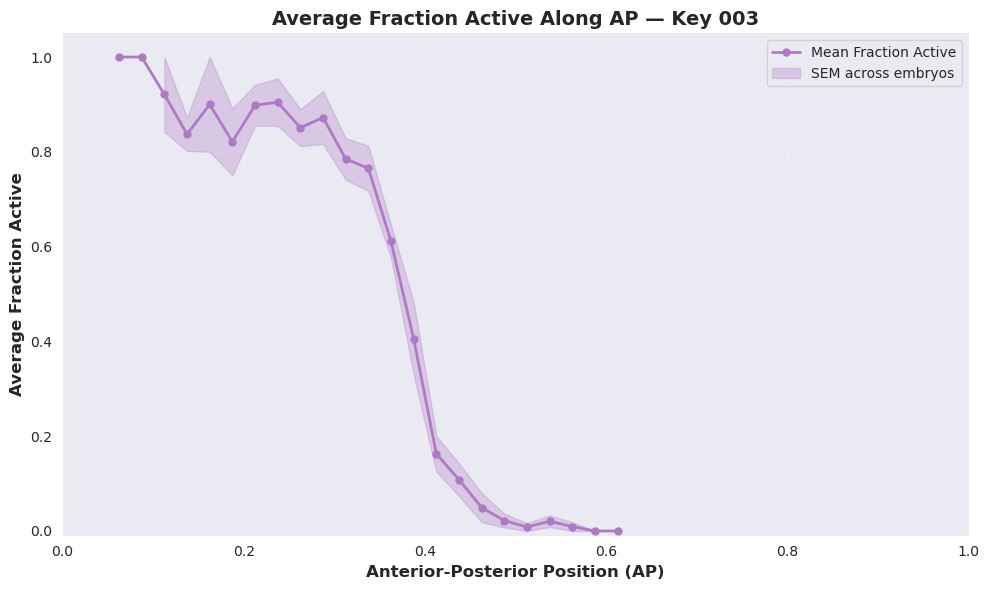

In [15]:
# Average fraction active vs AP across all embryos within a selected key
key = '003'  # choose which key to aggregate in the second cell
if key in embryo_list:
    embryos = embryo_list[key]
    loaded = [load_fraction_summary(ds) for ds in embryos]
    loaded = [df for df in loaded if df is not None]

    if loaded:
        # Align by ap_bin_center (they should match across datasets)
        x = loaded[0]['ap_bin_center'].to_numpy()
        Y = np.stack([df['fraction_active'].to_numpy() for df in loaded], axis=0)

        mean_frac = np.nanmean(Y, axis=0)
        sem_frac = np.nanstd(Y, axis=0, ddof=1) / np.sqrt(np.sum(~np.isnan(Y), axis=0))

        fig, ax = plt.subplots(figsize=(10, 6))
        ax.plot(x, mean_frac, linestyle='-', marker='o', markersize=5, color='#AF7AC5', linewidth=2, label='Mean Fraction Active')
        ax.fill_between(x, np.maximum(mean_frac - sem_frac, 0), np.minimum(mean_frac + sem_frac, 1.0), alpha=0.3, color='#AF7AC5', label='SEM across embryos')

        ax.set_xlim(0.0, 1.0)
        ax.set_ylim(-0.01, 1.05)
        ax.set_xlabel('Anterior-Posterior Position (AP)', fontsize=12, fontweight='bold')
        ax.set_ylabel('Average Fraction Active', fontsize=12, fontweight='bold')
        ax.set_title(f'Average Fraction Active Along AP — Key {key}', fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.legend(fontsize=10)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        plt.tight_layout()
        plt.show()
    else:
        print(f'No fraction_active_time_filtered.pkl found for key {key}.')
else:
    print(f'Key {key} not found in embryo_list.')


In [16]:
# Loop through each group and compute group-level average fraction active

group_averages = {}

for group_key, embryos in embryo_list.items():
    loaded = [load_fraction_summary(ds) for ds in embryos]
    loaded = [df for df in loaded if df is not None]

    if not loaded:
        continue

    # Stack fraction_active values across all embryos in this group
    x = loaded[0]['ap_bin_center'].to_numpy()
    Y = np.stack([df['fraction_active'].to_numpy() for df in loaded], axis=0)

    mean_frac = np.nanmean(Y, axis=0)
    sem_frac = np.nanstd(Y, axis=0, ddof=1) / np.sqrt(np.sum(~np.isnan(Y), axis=0))

    group_averages[group_key] = {
        'ap_bin_center': x,
        'mean_fraction': mean_frac,
        'sem_fraction': sem_frac
    }

/tmp/ipykernel_3576363/674699724.py:16: RuntimeWarning: Mean of empty slice
  mean_frac = np.nanmean(Y, axis=0)
/mnt/Data1/Nick/miniforge3/envs/transcription_pipeline/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_3576363/674699724.py:16: RuntimeWarning: Mean of empty slice
  mean_frac = np.nanmean(Y, axis=0)
/mnt/Data1/Nick/miniforge3/envs/transcription_pipeline/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_3576363/674699724.py:16: RuntimeWarning: Mean of empty slice
  mean_frac = np.nanmean(Y, axis=0)
/mnt/Data1/Nick/miniforge3/envs/transcription_pipeline/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtyp

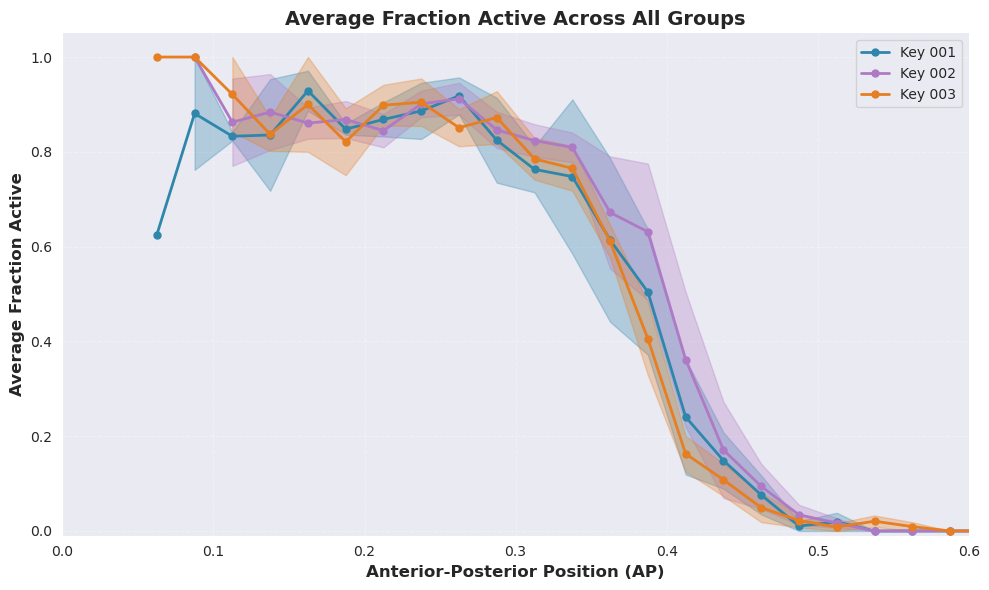

In [17]:
# Plot overlaid group averages

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#2E86AB', '#AF7AC5', '#E67E22']

for (group_key, data), color in zip(group_averages.items(), colors):
    x = data['ap_bin_center']
    mean_frac = data['mean_fraction']
    sem_frac = data['sem_fraction']

    ax.plot(x, mean_frac, linestyle='-', marker='o', markersize=5,
            color=color, linewidth=2, label=f'Key {group_key}')
    ax.fill_between(x,
                    np.maximum(mean_frac - sem_frac, 0),
                    np.minimum(mean_frac + sem_frac, 1.0),
                    alpha=0.3, color=color)

ax.set_xlim(0.0, 0.6)
ax.set_ylim(-0.01, 1.05)
ax.set_xlabel('Anterior-Posterior Position (AP)', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Fraction Active', fontsize=12, fontweight='bold')
ax.set_title('Average Fraction Active Across All Groups', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()
